# Библиотеки

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import seaborn as sns

## 9.12 Сравнение незав. групп:более 2-х групп,параметрика,с пост-хок

In [2]:
d = pd.read_excel('./data/Patients.xlsx')

In [3]:
bins = [0, 55, 65, 75, float('inf')]  # границы интервалов
age_labels = ['1. до 55 лет', '2. 56-65 лет', '3. 66 - 75 лет', '4. старше 75 лет']

d = d.assign(age_groups = lambda df: pd.cut(x=df['Возраст'], bins=bins, labels=age_labels)).rename(columns={'age_groups':'Возрастная_группа'})

In [4]:
d.head()

,ID,Вес,Возраст,Возрастная_группа
0,1,70,66,3. 66 - 75 лет
1,2,63,58,2. 56-65 лет
2,3,70,47,1. до 55 лет
3,4,48,80,4. старше 75 лет
4,5,77,52,1. до 55 лет


In [5]:
d['Возрастная_группа'].value_counts()

Возрастная_группа
1. до 55 лет        52
2. 56-65 лет        51
3. 66 - 75 лет      47
4. старше 75 лет    24
Name: count, dtype: int64

In [6]:
pg.homoscedasticity(data=d, dv='Вес', group='Возрастная_группа')

,W,pval,equal_var
levene,0.145153,0.932672,True


In [7]:
pg.anova(data=d, dv='Вес', between='Возрастная_группа')

,Source,ddof1,ddof2,F,p-unc,np2
0,Возрастная_группа,3,170,7.309805,0.000122,0.114258


In [8]:
pg.pairwise_tukey(d, dv='Вес', between='Возрастная_группа')

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,1. до 55 лет,2. 56-65 лет,79.961538,72.960784,7.000754,2.364700,2.960525,0.018266,0.558935
1,1. до 55 лет,3. 66 - 75 лет,79.961538,70.425532,9.536007,2.414967,3.948710,0.000659,0.742340
2,1. до 55 лет,4. старше 75 лет,79.961538,68.750000,11.211538,2.961037,3.786356,0.001203,0.838751
3,2. 56-65 лет,3. 66 - 75 лет,72.960784,70.425532,2.535252,2.426182,1.044956,0.723253,0.229609
4,2. 56-65 лет,4. старше 75 лет,72.960784,68.750000,4.210784,2.970190,1.417682,0.490080,0.381377
5,3. 66 - 75 лет,4. старше 75 лет,70.425532,68.750000,1.675532,3.010363,0.556588,0.944644,0.146201


## 9.13 Сравнение незав. групп:более 2-х групп,непараметрика, с пост-хок

In [9]:
d

,ID,Вес,Возраст,Возрастная_группа
0,1,70,66,3. 66 - 75 лет
1,2,63,58,2. 56-65 лет
2,3,70,47,1. до 55 лет
3,4,48,80,4. старше 75 лет
4,5,77,52,1. до 55 лет
...,...,...,...,...
169,170,65,63,2. 56-65 лет
170,171,77,65,2. 56-65 лет
171,172,79,61,2. 56-65 лет
172,173,52,70,3. 66 - 75 лет


In [10]:
pg.pairwise_tests(data=d.loc[d['Возрастная_группа'].isin(['1. до 55 лет', '4. старше 75 лет'])],
                  dv='Вес',
                  between='Возрастная_группа'
                 )

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,Возрастная_группа,1. до 55 лет,4. старше 75 лет,False,True,3.689905,53.772972,two-sided,0.000525,62.847,0.838751


In [11]:
pg.pairwise_tests(
    data=d.loc[d['Возрастная_группа'].isin(['1. до 55 лет', '4. старше 75 лет'])],
    dv='Вес',
    between='Возрастная_группа',
    parametric=False
)

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,hedges
0,Возрастная_группа,1. до 55 лет,4. старше 75 лет,False,False,902.5,two-sided,0.001872,0.838751


In [12]:
pg.pairwise_tests(data=d, dv='Вес', between='Возрастная_группа', padjust='bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Возрастная_группа,1. до 55 лет,2. 56-65 лет,False,True,2.864780,95.353403,two-sided,0.005133,0.030799,bonf,7.425,0.558935
1,Возрастная_группа,1. до 55 лет,3. 66 - 75 лет,False,True,3.757372,95.829521,two-sided,0.000295,0.001770,bonf,85.681,0.742340
2,Возрастная_группа,1. до 55 лет,4. старше 75 лет,False,True,3.689905,53.772972,two-sided,0.000525,0.003147,bonf,62.847,0.838751
3,Возрастная_группа,2. 56-65 лет,3. 66 - 75 лет,False,True,1.141949,94.231155,two-sided,0.256369,1.000000,bonf,0.379,0.229609
4,Возрастная_группа,2. 56-65 лет,4. старше 75 лет,False,True,1.515513,42.269454,two-sided,0.137086,0.822514,bonf,0.667,0.381377
5,Возрастная_группа,3. 66 - 75 лет,4. старше 75 лет,False,True,0.585509,45.656866,two-sided,0.561089,1.000000,bonf,0.296,0.146201


In [13]:
pg.pairwise_tests(data=d, dv='Вес', between='Возрастная_группа', padjust='bonf', parametric=False)

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Возрастная_группа,1. до 55 лет,2. 56-65 лет,False,False,1745.0,two-sided,0.005715,0.034291,bonf,0.558935
1,Возрастная_группа,1. до 55 лет,3. 66 - 75 лет,False,False,1761.0,two-sided,0.000158,0.000947,bonf,0.742340
2,Возрастная_группа,1. до 55 лет,4. старше 75 лет,False,False,902.5,two-sided,0.001872,0.011232,bonf,0.838751
3,Возрастная_группа,2. 56-65 лет,3. 66 - 75 лет,False,False,1373.5,two-sided,0.213934,1.000000,bonf,0.229609
4,Возрастная_группа,2. 56-65 лет,4. старше 75 лет,False,False,722.0,two-sided,0.213169,1.000000,bonf,0.381377
5,Возрастная_группа,3. 66 - 75 лет,4. старше 75 лет,False,False,592.5,two-sided,0.733353,1.000000,bonf,0.146201


## 10.3 Корреляции

In [17]:
d.head(3)

,ID,Вес,Возраст,Возрастная_группа
0,1,70,66,3. 66 - 75 лет
1,2,63,58,2. 56-65 лет
2,3,70,47,1. до 55 лет


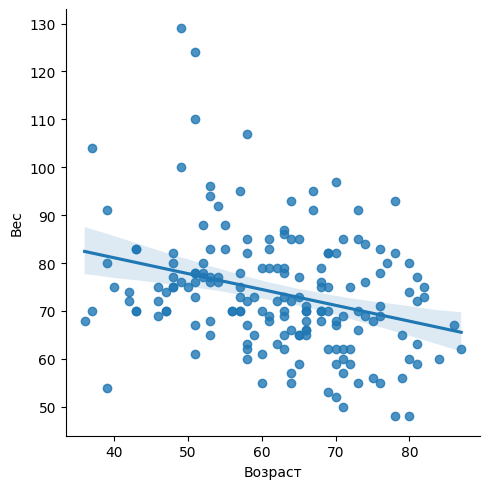

In [21]:
sns.lmplot(data=d, x='Возраст', y='Вес', )

In [22]:
pg.corr(d['Возраст'], d['Вес'], method='pearson')

,n,r,CI95%,p-val,BF10,power
pearson,174,-0.302463,"[-0.43, -0.16]",0.00005,331.067,0.983562


In [24]:
d.corr(method='pearson', numeric_only=True)

,ID,Вес,Возраст
ID,1.000000,-0.219663,0.261529
Вес,-0.219663,1.000000,-0.302463
Возраст,0.261529,-0.302463,1.000000


In [25]:
pg.normality(d, method='shapiro')

,W,pval,normal
ID,0.954609,0.000021,False
Вес,0.944725,0.000003,False
Возраст,0.986552,0.094297,True


In [27]:
pg.normality(d, method='normaltest')

,W,pval,normal
ID,76.755072,2.152028e-17,False
Вес,40.604439,1.523555e-09,False
Возраст,6.391962,4.092635e-02,False


In [28]:
pg.corr(d['Возраст'], d['Вес'], method='bicor')

,n,r,CI95%,p-val,power
bicor,174,-0.277816,"[-0.41, -0.13]",0.000206,0.96252


<Axes: >

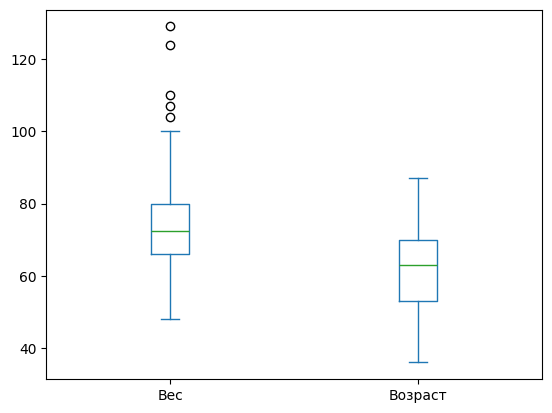

In [29]:
d[['Вес','Возраст']].plot.box()

In [30]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   ID                 174 non-null    int64   
 1   Вес                174 non-null    int64   
 2   Возраст            174 non-null    int64   
 3   Возрастная_группа  174 non-null    category
dtypes: category(1), int64(3)
memory usage: 4.6 KB


In [35]:
d['Вкат'] = d['Возрастная_группа'].cat.rename_categories(new_categories={'1. до 55 лет':1, '2. 56-65 лет':2, '3. 66 - 75 лет':3, '4. старше 75 лет':4})

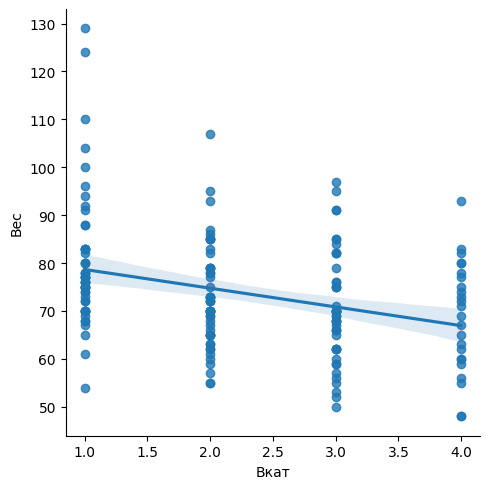

In [37]:
sns.lmplot(data=d, x='Вкат', y='Вес')

In [38]:
pg.corr(d['Вкат'], d['Вес'])

,n,r,CI95%,p-val,BF10,power
pearson,174,-0.319363,"[-0.45, -0.18]",0.000017,890.233,0.991318


In [39]:
pg.corr(d['Вкат'], d['Вес'], method='shepherd')

,n,outliers,r,CI95%,p-val,power
shepherd,174,6,-0.296752,"[-0.43, -0.15]",0.000094,0.976187


In [40]:
bins = [0, 60, 80, 100, float('inf')]
labels = [1, 2, 3, 4] 

d['ВесК'] = pd.cut(d['Вес'], bins=bins, labels=labels, right=True)

In [42]:
pg.corr(d['Вкат'], d['ВесК'], method='kendall')

,n,r,CI95%,p-val,power
kendall,174,-0.222085,"[-0.36, -0.08]",0.000862,0.841585


In [43]:
pg.corr(d['Вкат'], d['ВесК'], method='spearman')

,n,r,CI95%,p-val,power
spearman,174,-0.252343,"[-0.39, -0.11]",0.000782,0.922407
